# S7-1 ハザードレートとサバイバル確率

## 学習目標

- デフォルト時刻をポアソン過程の第1到着時刻としてモデル化し、生存関数
  $S(t)=\exp\!\big(-\!\int_0^t \lambda(u)\,du\big)$ を導出できる
- ハザードレート・サバイバル確率・デフォルト密度の三者を式で結び付けられる
- リスキーなキャッシュフローの現在価値を「無リスク割引・生存・回収」の3成分に
  分解して評価できる
- 区分定数ハザードカーブとリスキー債券評価器をスクラッチ実装し、
  `bondlab.credit.HazardCurve` と一致することを確認できる
- $\lambda$ 一定の解析解 $S(t)=e^{-\lambda t}$ と突合し、近似式
  $s \approx \lambda(1-R)$ の精度と限界をパラメータ範囲で検証できる

## 実務での位置づけ（ファンドはどう稼ぐか）

ハザードレートと生存確率は、クレジットデスクが「信用リスクをいくらで売り買いするか」を数量化する土台です。docs の枠組みでいうと、クレジットデスクは個社の信用力（ミクロ）を見て社債・CDS に値付けします。その値付けの中身は、市場が織り込むデフォルト強度 $\lambda$ と回収率 $R$ です。リスキーなキャッシュフローを「無リスク割引 $\times$ 生存 $+$ デフォルト時回収」に分解できると、観測されるスプレッド $s$ から市場のインプライド・ハザードを逆算でき、逆に自分のハザード観から理論価格を出せます。近似式 $s \approx \lambda(1-R)$ は、スプレッドとデフォルト強度・回収率がどう噛み合うかを一目で示す実務の勘所です。

クレジットのキャリー収益は、この生存確率の裏返しです。社債やプロテクション売りを保有すると、生存している間はスプレッド分の利息（キャリー）が積み上がりますが、その対価としてデフォルトで元本を失うリスク（$1-R$ の損失を確率 $\mathrm{d}(1-S)$ で被る）を引き受けています。リスク中立の生存確率で割り引いた期待値がフェアなら、キャリーは「デフォルト損失の期待値」をちょうど埋め合わせる水準に決まります。ファンドが超過リターンを狙うのは、自分のハザード推定が市場のインプライドより低い（＝スプレッドが割高で、実際のデフォルトはそこまで起きない）と読むときで、その乖離の平均回帰が相対価値のアルファになります。

XVA デスクにとっても生存確率は必須の部品です。S7-5 で扱う CVA は $(1-R)\int_0^T \mathbb{E}[D(t)V(t)^+]\,\mathrm{d}(1-S(t))$ の形で、カウンターパーティの生存確率 $S(t)$ をそのまま積分核に使います。ここで組んだ区分定数ハザードカーブとリスキー割引の考え方が、CDS ブートストラップ（S7-2）を経て CVA 計算まで一本の線でつながります。


## 理論

### デフォルト時刻のモデル化：ポアソン過程と強度 $\lambda$

信用リスクの出発点は、デフォルトを「いつ起きるか分からない1回だけのイベント」
として扱うことです。強度モデル（intensity model, 誘導形モデル）では、デフォルト
の到来を強度 $\lambda$ のポアソン過程における最初のジャンプとして表します。

強度 $\lambda$ の（斉次）ポアソン過程では、微小区間 $[t, t+dt]$ にイベントが1回
起きる確率が $\lambda\,dt$、生存中に起きる回数の期待値が時間に比例します。デフォルト
時刻 $\tau$ を「最初のジャンプ時刻（第1到着時刻）」と定義すると、$\tau$ が $t$ より
先に来ない確率、すなわち時点 $t$ まで生き残る確率は次で与えられます。

$$
S(t) = \mathbb{P}(\tau > t) = e^{-\lambda t}.
$$

これは「$[0,t]$ でジャンプが0回」というポアソン確率 $e^{-\lambda t}(\lambda t)^0/0!$
そのものです。強度 $\lambda$ が時間とともに変わる非斉次過程に一般化すると、指数の
肩が積分に変わります。

$$
S(t) = \exp\!\left(-\int_0^t \lambda(u)\,du\right).
$$

### サバイバル確率・ハザードレート・デフォルト密度

デフォルト時刻 $\tau$ の累積分布 $F(t)=\mathbb{P}(\tau \le t)=1-S(t)$、密度
$f(t)=F'(t)=-S'(t)$ とすると、ハザードレート（hazard rate）は

$$
\lambda(t) = \frac{f(t)}{S(t)} = -\frac{S'(t)}{S(t)} = -\frac{d}{dt}\ln S(t)
$$

と定義されます。「いま時点 $t$ まで生存している条件のもとで、直後に瞬間的に
デフォルトする速度」です。この式を積分し直すと $S(t)=\exp(-\int_0^t\lambda)$ に
戻り、デフォルト密度は

$$
f(t) = \lambda(t)\,S(t)
$$

と書けます。累積ハザード $\Lambda(t)=\int_0^t\lambda(u)\,du$ を使えば
$S(t)=e^{-\Lambda(t)}$ です。本 notebook では $\lambda$ を区分定数（各区間で一定）
とするので、$\Lambda(t)$ は区間ごとの $\lambda \times$ 区間長を足し上げた折れ線に
なり、$S(t)$ は区間ごとに傾きの変わる指数減衰になります。

### リスキー割引：生存確率で割り引く

満期 $t$ に額面1を払う無リスク割引債の価格は割引係数 $DF(t)$ です。同じ将来
キャッシュフローがデフォルトすると消える（回収なし）なら、支払われるのは
「生き残ったとき」だけなので、その現在価値は

$$
\tilde{DF}(t) = DF(t)\,S(t)
$$

となります。無リスク割引に生存確率を掛けた量を**リスキー割引係数**と呼びます。
生存確率は割引係数と同じ「将来価値を割り引く」役割を持ち、両者は掛け算で合成
されます。連続複利で書けば $DF(t)=e^{-r t}$、$S(t)=e^{-\lambda t}$ なので
$\tilde{DF}(t)=e^{-(r+\lambda)t}$ となり、ハザード $\lambda$ はゼロレートへの
上乗せ（スプレッド）としてそのまま効きます。

### 回収率の扱い：40% 慣行の根拠と限界

実際にはデフォルトしても額面の一部は回収されます。回収率（recovery rate）$R$ は
デフォルト時に取り戻せる額面比率で、無担保シニア債では慣行的に $R=40\%$ が
使われます。根拠は、ムーディーズや S&P が集計した過去のデフォルト債の平均回収率
が無担保シニアでおおむね 40% 前後に集まる、という実績です。ただしこれは平均像に
すぎず、次の限界があります。

- 回収率は担保・弁済順位で大きく変わる（担保付きは高く、劣後・ジュニアは低い）
- 景気に連動し、デフォルトが増える不況期ほど回収率は下がる（$\lambda$ と $R$ は
  独立でなく負に相関しやすい）
- 業種・法域・清算か再建かでも分布が広い

したがって $R=40\%$ は「他に情報がないときの出発点」であり、実務では銘柄ごとに
見直します。本 notebook では基準ケースとして 40% を置きつつ、後半で $R$ を動かして
価格・スプレッドがどう変わるかを見ます。

### リスキー割引の3成分分解

回収を入れたリスキー債券の価格は、3つの現在価値の和に分解できます。クーポン
$c_i$ を時点 $t_i$（$i=1,\dots,n$、満期 $t_n=T$）に払い、額面 $F$ を満期に返す債券で、
デフォルト時には額面の $R$ 倍がその区間の中央で回収されると近似すると、

$$
P = \underbrace{\sum_{i=1}^{n} c_i\, DF(t_i)\, S(t_i)}_{\text{(1) クーポン（生存加重）}}
  + \underbrace{F\, DF(T)\, S(T)}_{\text{(2) 元本（生存加重）}}
  + \underbrace{R\,F \sum_{i=1}^{n} DF(\bar t_i)\,\big(S(t_{i-1})-S(t_i)\big)}_{\text{(3) 回収}}.
$$

ここで $\bar t_i=(t_{i-1}+t_i)/2$、$S(t_{i-1})-S(t_i)$ は区間 $(t_{i-1},t_i]$ で
デフォルトする確率です。成分(1)(2)は「無リスク割引 $\times$ 生存確率」で、成分(3)が
「デフォルト時の回収」です。$R=0$ なら回収項が消え、$\lambda\to 0$ なら $S\equiv 1$
で無リスク債に戻ります。

この分解から、信用スプレッドの近似式が読み取れます。連続時間・一定 $\lambda$・
一定 $R$ の極限で、リスキー債のスプレッド（無リスク金利への上乗せ）は

$$
s \approx \lambda\,(1-R)
$$

に近づきます。直感的には「単位時間あたりデフォルト確率 $\lambda$ のうち、投資家が
失うのは損失率 $(1-R)$ の分だけ」だからです。$1-R$ は損失率（loss given default,
LGD）です。この近似は $\lambda$ と $R$ が小さいほどよく当たり、$\lambda$ が大きい
ときや割引・複利効果が効くと系統的にずれます。後半で誤差を定量化します。

**数値例**：$\lambda=0.02$、$t=5$ 年のとき、生存確率は $S(5)=e^{-0.02\times 5}=e^{-0.1}\approx 0.9048$ です（5年後までデフォルトしない確率は約 90.5%）。

**数値例**：無リスクゼロレート $r=0.03$ を重ねると、リスキー割引係数は $\tilde{DF}(5)=e^{-(0.03+0.02)\times 5}=e^{-0.25}\approx 0.7788$ となり、無リスク割引 $DF(5)=e^{-0.15}\approx 0.8607$ に生存確率 $S(5)\approx 0.9048$ を掛けた値に一致します。

**数値例**：$\lambda=0.02$、$R=0.4$ なら近似スプレッドは $s\approx \lambda(1-R)=0.02\times(1-0.4)=0.012$（120bp）です。


## スクラッチ実装

区分定数ハザードカーブと、それを使うリスキー債券評価器を numpy で自作します。
実装後に `bondlab.credit.HazardCurve` と突合します。

### 使用する自作関数・クラス

| 名前 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `PiecewiseHazard(times, hazards)` | 区間右端の配列, 各区間の $\lambda$ | インスタンス | 区分定数ハザードカーブを保持 |
| `.cumulative_hazard(t)` | 年数（スカラ/配列） | $\Lambda(t)$ | 累積ハザード $\int_0^t\lambda$ を折れ線積分 |
| `.survival(t)` | 年数 | $S(t)$ | 生存確率 $e^{-\Lambda(t)}$ |
| `.default_prob(t)` | 年数 | $1-S(t)$ | 時点 $t$ までの累積デフォルト確率 |
| `.default_density(t)` | 年数 | $f(t)=\lambda(t)S(t)$ | デフォルト時刻の確率密度 |
| `.hazard_at(t)` | 年数 | $\lambda(t)$ | 時点 $t$ が属する区間の $\lambda$ |
| `risky_bond_pv(...)` | 下表参照 | dict（3成分と価格） | リスキー債券を3成分に分解して評価 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import bondlab
from bondlab.credit import HazardCurve
from bondlab.curve import bootstrap_par

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


class PiecewiseHazard:
    """区分定数ハザードレート λ による生存確率カーブ（自作）。

    times は各区間の右端（年、昇順）、hazards は対応する区間のハザード。
    最終ノードより先は最後のハザードで外挿する（bondlab.credit.HazardCurve と同じ規約）。
    """

    def __init__(self, times, hazards):
        self.times = np.asarray(times, dtype=float)
        self.hazards = np.asarray(hazards, dtype=float)
        if self.times.shape != self.hazards.shape:
            raise ValueError("times と hazards は同じ長さ")
        # 区間の左端 0 を先頭に付けた境界と、各ノードでの累積ハザードを前計算する。
        self._edges = np.concatenate([[0.0], self.times])
        self._cumnodes = np.concatenate(
            [[0.0], np.cumsum(np.diff(self._edges) * self.hazards)]
        )

    def _cum_one(self, tt):
        """スカラ tt に対する累積ハザード Λ(tt)。"""
        if tt <= 0:
            return 0.0
        i = int(np.searchsorted(self.times, tt))
        if i >= len(self.times):  # 最終ノードより先は最後の λ で延長
            return self._cumnodes[-1] + (tt - self.times[-1]) * self.hazards[-1]
        return self._cumnodes[i] + (tt - self._edges[i]) * self.hazards[i]

    def cumulative_hazard(self, t):
        """累積ハザード Λ(t)=∫_0^t λ。スカラ入力にはスカラ、配列には配列を返す。"""
        t = np.asarray(t, dtype=float)
        if t.ndim == 0:
            return self._cum_one(float(t))
        return np.array([self._cum_one(float(x)) for x in t])

    def survival(self, t):
        """生存確率 S(t)=exp(-Λ(t))。"""
        return np.exp(-self.cumulative_hazard(t))

    def default_prob(self, t):
        """時点 t までの累積デフォルト確率 1-S(t)。"""
        return 1.0 - self.survival(t)

    def hazard_at(self, t):
        """時点 t が属する区間のハザード λ(t)（区分定数）。"""
        t = np.asarray(t, dtype=float)
        idx = np.searchsorted(self.times, t, side="left")
        idx = np.clip(idx, 0, len(self.hazards) - 1)
        return self.hazards[idx]

    def default_density(self, t):
        """デフォルト時刻の確率密度 f(t)=λ(t)S(t)。"""
        return self.hazard_at(t) * self.survival(t)

bondlab version: 0.0.1


### リスキー債券評価器

前節の3成分分解をそのまま関数にします。返り値はクーポン・元本・回収の各現在価値と
合計価格の dict です。

| 引数 | 意味 |
|---|---|
| `disc` | 割引カーブ（`.discount(t)` を持つ。`bondlab.curve.DiscountCurve`） |
| `haz` | ハザードカーブ（`.survival(t)` を持つ） |
| `coupon` | 年クーポン率（小数） |
| `maturity` | 満期（年） |
| `face` | 額面 |
| `recovery` | 回収率 $R$ |
| `freq` | 年間クーポン回数 |

In [2]:
def risky_bond_pv(disc, haz, coupon, maturity, face=100.0, recovery=0.4, freq=2):
    """リスキー固定利付債を3成分（クーポン・元本・回収）に分解して評価する。

    Returns
    -------
    dict(coupon_pv, principal_pv, recovery_pv, price)
    """
    tau = 1.0 / freq
    n = int(round(maturity * freq))
    times = np.arange(1, n + 1) * tau            # 利払時点
    df = disc.discount(times)
    surv = haz.survival(times)

    # (1) クーポン（生存加重）
    coupon_pv = float(np.sum(coupon * tau * face * df * surv))
    # (2) 元本（生存加重）
    principal_pv = float(face * disc.discount(maturity) * haz.survival(maturity))
    # (3) 回収：区間中央で回収されると近似
    prev = np.concatenate([[0.0], times[:-1]])
    surv_prev = haz.survival(prev)
    dflt_prob = surv_prev - surv                 # 区間内デフォルト確率
    mid = 0.5 * (prev + times)
    recovery_pv = float(recovery * face * np.sum(disc.discount(mid) * dflt_prob))

    price = coupon_pv + principal_pv + recovery_pv
    return dict(
        coupon_pv=coupon_pv,
        principal_pv=principal_pv,
        recovery_pv=recovery_pv,
        price=price,
    )


# 動作確認：区分定数ハザードカーブを1本作り、生存確率を表示する。
times = np.array([1.0, 3.0, 5.0, 10.0])
hazards = np.array([0.010, 0.015, 0.020, 0.030])
my_haz = PiecewiseHazard(times, hazards)

for t in [0.5, 1.0, 2.0, 5.0, 7.0, 10.0]:
    print(f"t={t:5.1f}  Λ(t)={my_haz.cumulative_hazard(t):.5f}  "
          f"S(t)={my_haz.survival(t):.6f}  f(t)={my_haz.default_density(t):.6f}")

t=  0.5  Λ(t)=0.00500  S(t)=0.995012  f(t)=0.009950
t=  1.0  Λ(t)=0.01000  S(t)=0.990050  f(t)=0.009900
t=  2.0  Λ(t)=0.02500  S(t)=0.975310  f(t)=0.014630
t=  5.0  Λ(t)=0.08000  S(t)=0.923116  f(t)=0.018462
t=  7.0  Λ(t)=0.14000  S(t)=0.869358  f(t)=0.026081
t= 10.0  Λ(t)=0.23000  S(t)=0.794534  f(t)=0.023836


### bondlab との一致確認

同じ入力で `bondlab.credit.HazardCurve` を作り、生存確率とデフォルト確率が一致する
ことを `assert` で守ります。

In [3]:
bl_haz = HazardCurve(times, hazards)
grid = np.linspace(0.0, 12.0, 25)

assert np.allclose(my_haz.survival(grid), bl_haz.survival(grid), atol=1e-12)
assert np.allclose(my_haz.default_prob(grid), bl_haz.default_prob(grid), atol=1e-12)
print("自作 PiecewiseHazard と bondlab.credit.HazardCurve は一致（生存・デフォルト確率）")

自作 PiecewiseHazard と bondlab.credit.HazardCurve は一致（生存・デフォルト確率）


## QuantLib検証

ここでの検証の柱は、$\lambda$ が一定のときの**解析解** $S(t)=e^{-\lambda t}$ との
突合です。区分定数実装を「全区間で同じ $\lambda$」に退化させれば、この閉じた式に
一致しなければなりません。あわせて QuantLib の `HazardRateCurve` とも突合し、外部
実装と一致することを確認します（QuantLib は自作コードの答え合わせ役に徹します）。

In [4]:
lam = 0.03
flat_my = PiecewiseHazard([5.0, 10.0], [lam, lam])   # 全区間 λ=0.03
flat_bl = HazardCurve([5.0, 10.0], [lam, lam])
tt = np.linspace(0.0, 10.0, 41)

analytic = np.exp(-lam * tt)
assert np.allclose(flat_my.survival(tt), analytic, atol=1e-12)  # 自作 vs 解析解
assert np.allclose(flat_bl.survival(tt), analytic, atol=1e-12)  # bondlab vs 解析解
print(f"λ={lam} 一定：自作・bondlab とも解析解 S(t)=exp(-λt) に一致")

# QuantLib の HazardRateCurve と突合する。
import QuantLib as ql

print("QuantLib version:", ql.__version__)

today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today
# 区分定数ハザード（自作 my_haz と同じノード・同じ λ）を QuantLib で構築する。
ql_dates = [today] + [today + ql.Period(int(round(t * 365)), ql.Days) for t in times]
ql_hazards = [hazards[0]] + list(hazards)   # 先頭ノードにも最初の λ を割り当てる
ql_curve = ql.HazardRateCurve(ql_dates, ql_hazards, ql.Actual365Fixed())

# survivalProbability は連続時間 Time（float）を受け取り、S(t)=exp(-Λ(t)) を返す。
ql_surv = np.array([ql_curve.survivalProbability(float(t)) for t in tt])
my_surv = my_haz.survival(tt)
max_diff = float(np.max(np.abs(ql_surv - my_surv)))
print(f"自作 vs QuantLib HazardRateCurve の生存確率 最大差: {max_diff:.2e}")
assert max_diff < 1e-10
print("QuantLib とも一致（区分定数ハザードの生存確率）")

λ=0.03 一定：自作・bondlab とも解析解 S(t)=exp(-λt) に一致
QuantLib version: 1.42.1
自作 vs QuantLib HazardRateCurve の生存確率 最大差: 1.11e-16
QuantLib とも一致（区分定数ハザードの生存確率）


## 実データ適用

市場データの代わりに、右肩上がりの合成ハザード期間構造（信用力がやや劣化していく
発行体を想定）を置き、生存確率・デフォルト密度・リスキー債券価格を可視化します。
割引カーブはフラットに近いパー利回りからブートストラップします。

/var/folders/1g/1cr93g5j1yn9cmnn2nz4ydt40000gn/T/ipykernel_97964/4016718989.py:4: UserWarning: bootstrap_par: テナーが等間隔でない。間のクーポン払込日を無視してカーブが歪む可能性がある。1/frequency 刻みのグリッドへ補間してから渡すことを推奨。
  disc = bootstrap_par(disc_tenors, disc_par, frequency=1)
findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


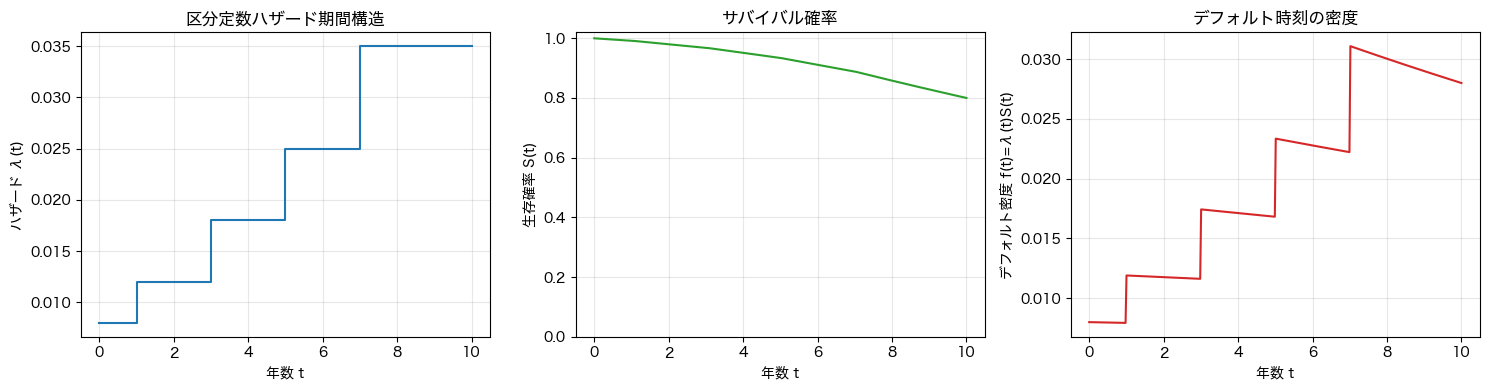

In [5]:
# 割引カーブ（無リスク）。年限ごとのパー利回りから割引係数を剥ぎ取る。
disc_tenors = [1, 2, 3, 5, 7, 10]
disc_par = [0.015, 0.017, 0.019, 0.021, 0.022, 0.023]
disc = bootstrap_par(disc_tenors, disc_par, frequency=1)

# 合成ハザード期間構造（区間右端と各区間の λ）。年限とともに増える。
haz_times = np.array([1.0, 3.0, 5.0, 7.0, 10.0])
haz_lams = np.array([0.008, 0.012, 0.018, 0.025, 0.035])
haz = HazardCurve(haz_times, haz_lams)

fine = np.linspace(0.0, 10.0, 400)
surv = haz.survival(fine)
dens = PiecewiseHazard(haz_times, haz_lams).default_density(fine)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].step(np.concatenate([[0.0], haz_times]),
             np.concatenate([[haz_lams[0]], haz_lams]),
             where="pre", color="#1f77b4")
axes[0].set_xlabel("年数 t")
axes[0].set_ylabel("ハザード λ(t)")
axes[0].set_title("区分定数ハザード期間構造")
axes[0].grid(alpha=0.3)

axes[1].plot(fine, surv, color="#2ca02c")
axes[1].set_xlabel("年数 t")
axes[1].set_ylabel("生存確率 S(t)")
axes[1].set_title("サバイバル確率")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)

axes[2].plot(fine, dens, color="#d62728")
axes[2].set_xlabel("年数 t")
axes[2].set_ylabel("デフォルト密度 f(t)=λ(t)S(t)")
axes[2].set_title("デフォルト時刻の密度")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

ハザードが上がる年限で $S(t)$ の減衰が速まり、密度 $f(t)=\lambda(t)S(t)$ はハザード
の段差で不連続にジャンプします（$\lambda$ が上がる）一方、生存確率 $S(t)$ が徐々に
小さくなるため、遠い将来では密度が頭打ち・減少に転じます。

### リスキー債券価格と3成分分解

クーポン3%・満期10年・額面100の債券を、回収率を変えて評価し、3成分の内訳を見ます。

In [6]:
print(f"{'R':>5} {'クーポンPV':>12} {'元本PV':>10} {'回収PV':>10} {'価格':>10}")
for R in [0.0, 0.2, 0.4, 0.6]:
    pv = risky_bond_pv(disc, haz, coupon=0.03, maturity=10.0, face=100.0,
                       recovery=R, freq=2)
    print(f"{R:>5.1f} {pv['coupon_pv']:>12.4f} {pv['principal_pv']:>10.4f} "
          f"{pv['recovery_pv']:>10.4f} {pv['price']:>10.4f}")

# 無リスク（λ=0）の同一債券価格を基準に、信用による値下がりを確認する。
riskless_haz = HazardCurve([10.0], [0.0])
pv_riskless = risky_bond_pv(disc, riskless_haz, 0.03, 10.0, 100.0, recovery=0.4)
print(f"\n無リスク同一債券の価格: {pv_riskless['price']:.4f}")

    R       クーポンPV       元本PV       回収PV         価格
  0.0      25.4209    69.7342     0.0000    95.1551
  0.2      25.4209    69.7342     3.6451    98.8002
  0.4      25.4209    69.7342     7.2903   102.4454
  0.6      25.4209    69.7342    10.9354   106.0905

無リスク同一債券の価格: 114.8293


回収率 $R$ を上げると回収成分(3)が増え、価格が上がります。$R=0$ でも回収項が
消えるだけで、クーポン・元本の生存加重成分は残ります。無リスク債（$\lambda=0$）と
比べた値下がり幅が信用リスクの対価です。

### 近似式 $s \approx \lambda(1-R)$ の精度

スプレッドの真値を、リスキーな割引ゼロクーポン債から閉じた式で取ります。満期 $t$ に
額面1を返し、デフォルト時は $R$ を満期に回収する（回収時点を満期に固定した簡便法）
ゼロ債のリスキー割引係数は、無リスク割引係数 $DF(t)$ に対し

$$
\tilde{DF}(t) = DF(t)\,\big[S(t) + R\,(1-S(t))\big]
$$

です。信用スプレッド $s$ を $\tilde{DF}(t)=DF(t)\,e^{-s t}$ で定義すると、割引カーブに
依存しない閉じた式

$$
s(\lambda, R, t) = -\frac{1}{t}\ln\!\big[S(t) + R\,(1-S(t))\big], \qquad S(t)=e^{-\lambda t}
$$

が得られます。$\lambda t$ が小さいとき $S \approx 1-\lambda t$ より
$S + R(1-S) \approx 1 - \lambda t (1-R)$、$-\ln(1-x)/t \approx \lambda(1-R)$ となり、
近似 $s \approx \lambda(1-R)$ はこの一次の項です。$\lambda$ と $R$ を動かして真値との
相対誤差を測ります。

**数値例**：5年リスキーゼロ債で厳密に測ると、$\lambda=0.02,\ R=0.4$ では真のスプレッドは約 117.6bp で、近似値 $\lambda(1-R)=120$bp との誤差は約 $+2\%$ にとどまります。一方 $\lambda=0.10$ まで上げると真値は約 538.6bp、近似 $\lambda(1-R)=600$bp となり誤差は約 $+11.4\%$ に拡大します（$\lambda$ が大きいほど過大評価側にずれる）。


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


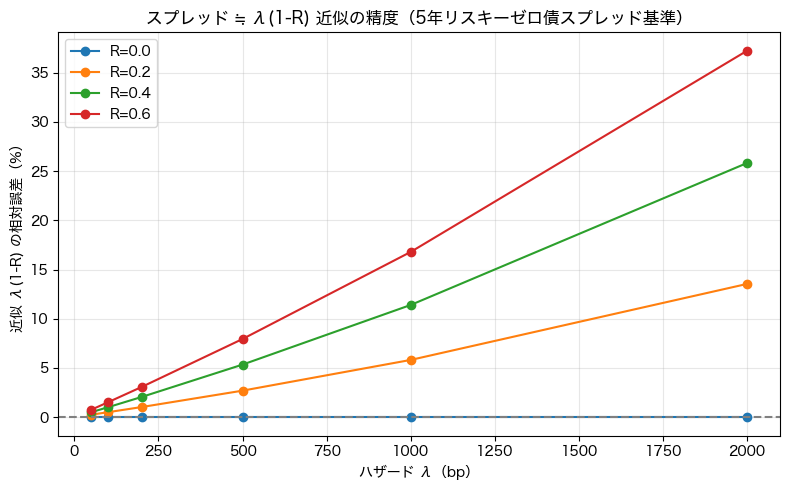

λ=    50bp  真のスプレッド=   29.85bp  λ(1-R)=   30.00bp  誤差= +0.50%
λ=   100bp  真のスプレッド=   59.40bp  λ(1-R)=   60.00bp  誤差= +1.01%
λ=   200bp  真のスプレッド=  117.58bp  λ(1-R)=  120.00bp  誤差= +2.05%
λ=   500bp  真のスプレッド=  284.79bp  λ(1-R)=  300.00bp  誤差= +5.34%
λ=  1000bp  真のスプレッド=  538.59bp  λ(1-R)=  600.00bp  誤差=+11.40%
λ=  2000bp  真のスプレッド=  953.73bp  λ(1-R)= 1200.00bp  誤差=+25.82%


In [7]:
def risky_zero_spread(lam, R, t):
    """リスキー割引ゼロ債（回収を満期に固定）の信用スプレッドを閉形式で返す。"""
    S = np.exp(-lam * t)
    return -np.log(S + R * (1 - S)) / t


lam_grid = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
R_grid = np.array([0.0, 0.2, 0.4, 0.6])
t_ref = 5.0

fig, ax = plt.subplots(figsize=(8, 5))
for R in R_grid:
    s_true = risky_zero_spread(lam_grid, R, t_ref)
    s_approx = lam_grid * (1 - R)
    rel_err = (s_approx - s_true) / s_true * 100
    ax.plot(lam_grid * 1e4, rel_err, "o-", label=f"R={R:.1f}")

ax.axhline(0.0, ls="--", color="gray")
ax.set_xlabel("ハザード λ（bp）")
ax.set_ylabel("近似 λ(1-R) の相対誤差（%）")
ax.set_title("スプレッド ≒ λ(1-R) 近似の精度（5年リスキーゼロ債スプレッド基準）")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

for lam in lam_grid:
    s_true = risky_zero_spread(lam, 0.4, t_ref)
    s_approx = lam * (1 - 0.4)
    print(f"λ={lam*1e4:6.0f}bp  真のスプレッド={s_true*1e4:8.2f}bp  "
          f"λ(1-R)={s_approx*1e4:8.2f}bp  誤差={(s_approx-s_true)/s_true*100:+6.2f}%")

$\lambda$ が小さい領域（数十 bp）では相対誤差は 1% 未満で近似はよく当たります。
$\lambda$ が大きくなる（10〜20%）ほど、生存確率の指数減衰の非線形性で真のスプレッドが
$\lambda(1-R)$ より小さくなり、近似は過大評価側（正の誤差）にずれます。$R$ を上げると
損失率 $(1-R)$ が縮んで一次項が小さくなるぶん、同じ $\lambda$ でも相対誤差は拡大します。
$R=0$ ではスプレッドが厳密に $\lambda$（$-\ln e^{-\lambda t}/t$）に一致し、誤差はゼロです。
実務のハイイールドや不況期のように $\lambda$ が大きい局面では、近似ではなくフル評価に
切り替える判断材料になります。

## 演習

1. **近似 $s \approx \lambda(1-R)$ の誤差マップ**：本文の `risky_zero_spread`
   （5年リスキーゼロ債スプレッド）を真値として、
   $\lambda \in \{50, 100, 300, 800\}$ bp、$R \in \{0.2, 0.4, 0.6, 0.8\}$ の
   全組み合わせで $\lambda(1-R)$ の相対誤差（%）を求め、表（行=$\lambda$, 列=$R$）に
   まとめよ。誤差が $\lambda$・$R$ のどちらに強く効くかを述べよ。
2. **折れ曲がる生存確率**：区分定数ハザード
   $\lambda=[0.01, 0.05, 0.01]$（区間右端 $[2, 4, 8]$ 年）で生存確率 $S(t)$ と
   $\ln S(t)$ を $t\in[0,8]$ でプロットせよ。$\ln S(t)$ が区間ごとに直線で、
   その傾きが $-\lambda$ になっていること（$\lambda$ が高い $[2,4]$ 年で急、
   低い区間で緩やか）を、傾きの数値で確認せよ。

解答例は `solutions/S7/sol_0701.py` に置く。

## 用語集

定義の正は `glossary/07_credit.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| ハザードレート | hazard rate | 生存を条件とした瞬間デフォルト速度 $\lambda(t)=-S'(t)/S(t)$ |
| サバイバル確率 | survival probability | 時点 $t$ までデフォルトしない確率 $S(t)=e^{-\int_0^t\lambda}$ |
| 回収率 | recovery rate | デフォルト時に回収できる額面比率 $R$（無担保シニアは慣行40%） |
| 強度モデル | intensity model | デフォルトを強度 $\lambda$ のポアソン過程の第1到着として表す誘導形モデル |
| リスキー割引 | risky discounting | 無リスク割引係数に生存確率を掛けて将来CFを割り引く手法 $DF(t)S(t)$ |